In [ ]:
run_all_forecasts

ETF ANALYSIS WITH THE CHOICE OF THE BEST MODEL
Load data from 2024-05-26 to 2026-05-26
SPY: 500 days
QQQ: 500 days
IWM: 500 days
The indicators for SPY
The indicators for QQQ
The indicators for IWM

The analysis is over!


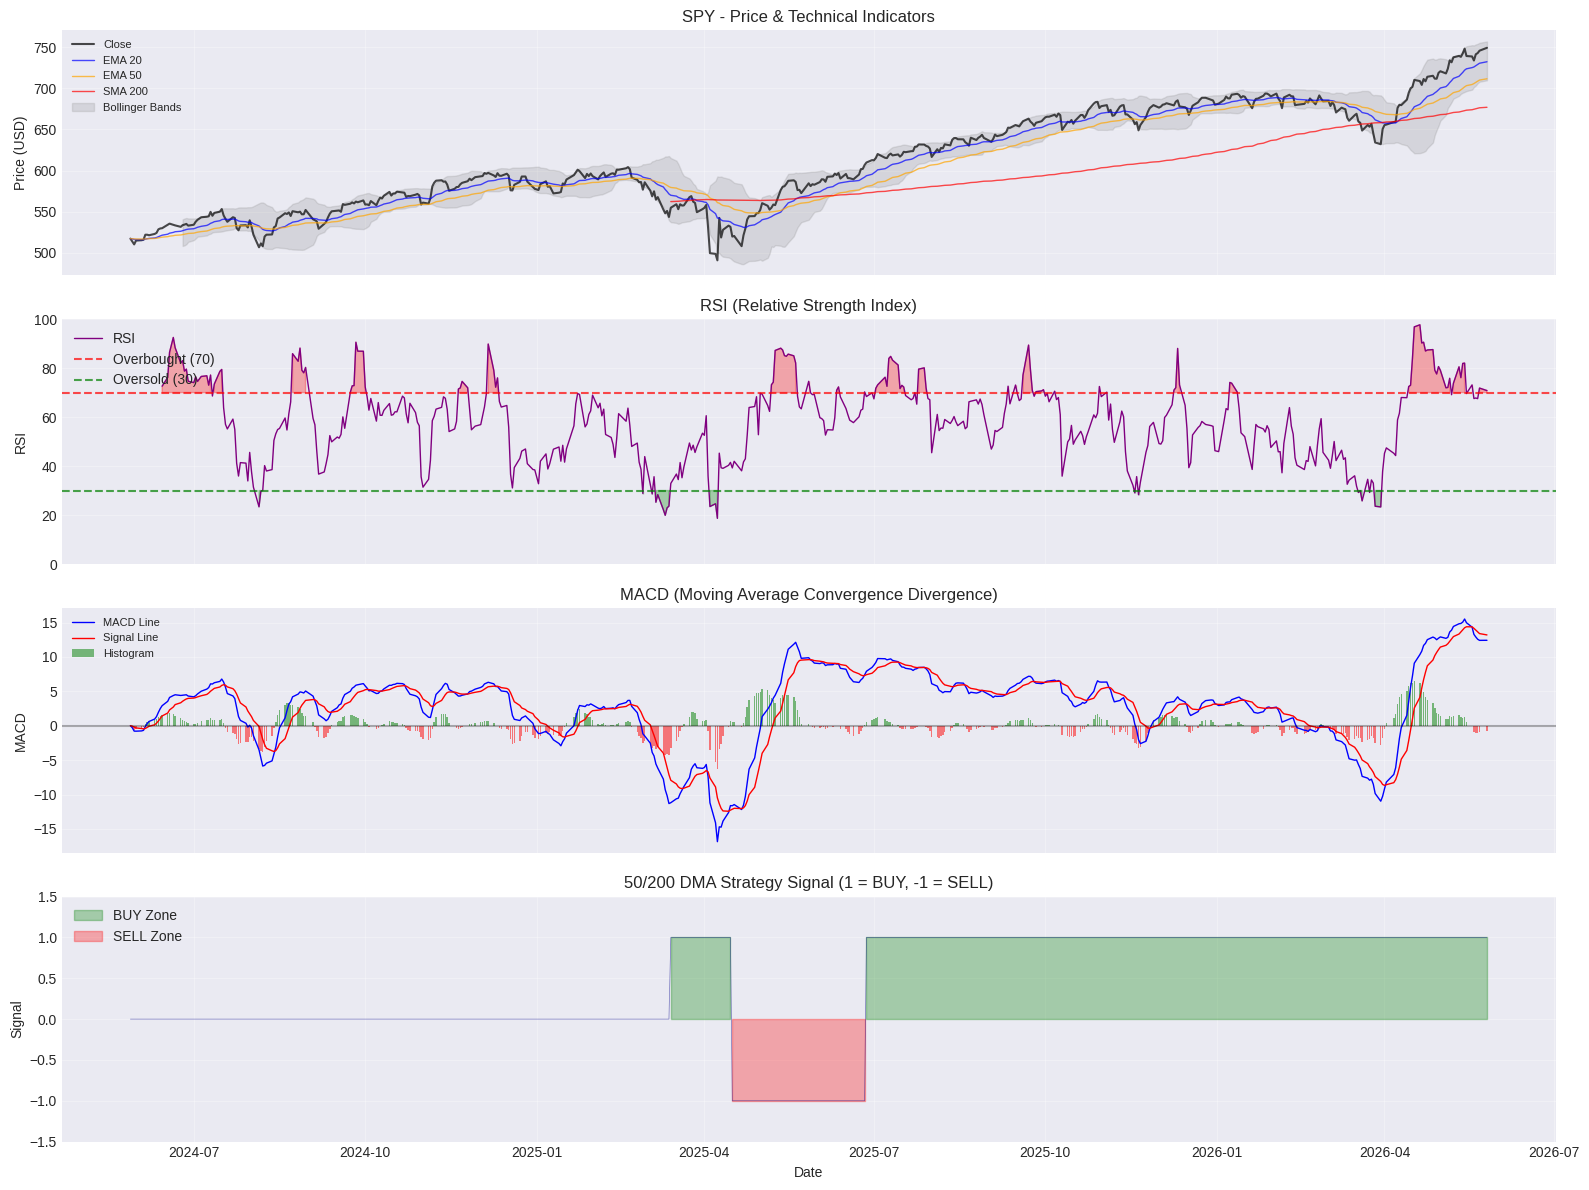

EMA vs SMA COMPARISON


,Period,SMA Smoothness,EMA Smoothness,Diff (%),Data Points
0,20,0.9826,1.0015,1.92,481
1,50,0.6267,0.6616,5.57,451
2,200,0.3900,0.3516,-9.84,301


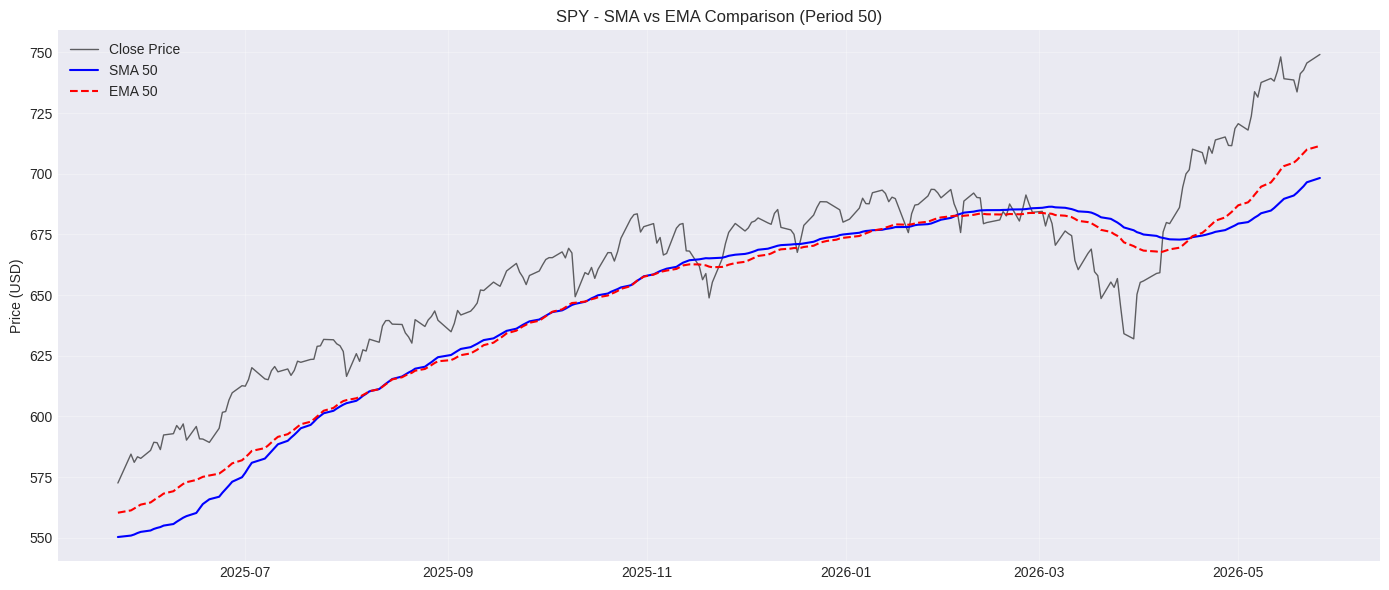

THE BEST MODEL FOR FORECASTING

     Analyzing the best model for SPY
use_differencing False
Train: 400 days, Test: 100 days
Original test length: 100 days
Avg price 612 > 300, LSTM and Hybrid disabled for stability
Testing Naive
 RMSE: 27.26, MAPE: 2.84%, Theil's U: 0.0198
Testing ETS
 RMSE: 27.53, MAPE: 4.00%, Theil's U: 0.0235
Testing ARIMA
ARIMA: (3, 1, 2)
 RMSE: 27.25, MAPE: 2.84%, Theil's U: 0.0198
Testing SARIMA
SARIMA: order=(1,1,1), seasonal_order=(0,1,1,5)
 RMSE: 28.54, MAPE: 4.16%, Theil's U: 0.0243
Testing Auto-SARIMA
SARIMA(0, 1, 0)x(0, 1, 1, 5): AIC=2527.1, DW=1.366, LB-p=0.0000
SARIMA(0, 1, 1)x(0, 1, 1, 5): AIC=2522.3, DW=1.360, LB-p=0.0000
SARIMA(0, 1, 2)x(0, 1, 1, 5): AIC=2515.2, DW=1.361, LB-p=0.0000

BEST AUTO-SARIMA FOUND:
Order: (0, 1, 2)
Seasonal Order: (0, 1, 1, 5)
AIC: 2515.2
Durbin-Watson: 1.361
Ljung-Box p-value: 0.0000
Still has positive autocorrelation (DW=1.361)
Try increasing AR order (p) or adding more differencing
 RMSE: 28.17, MAPE: 4.11%, Theil's U: 0.

,RMSE,MAE,MAPE (%),Theils U,Model Type
Ticker,,,,,
SPY,27.247052,19.879946,2.83752,0.019787,ARIMA
QQQ,36.156935,28.933427,5.843207,0.034243,ETS
IWM,14.438536,12.580588,4.730424,0.030707,SARIMA


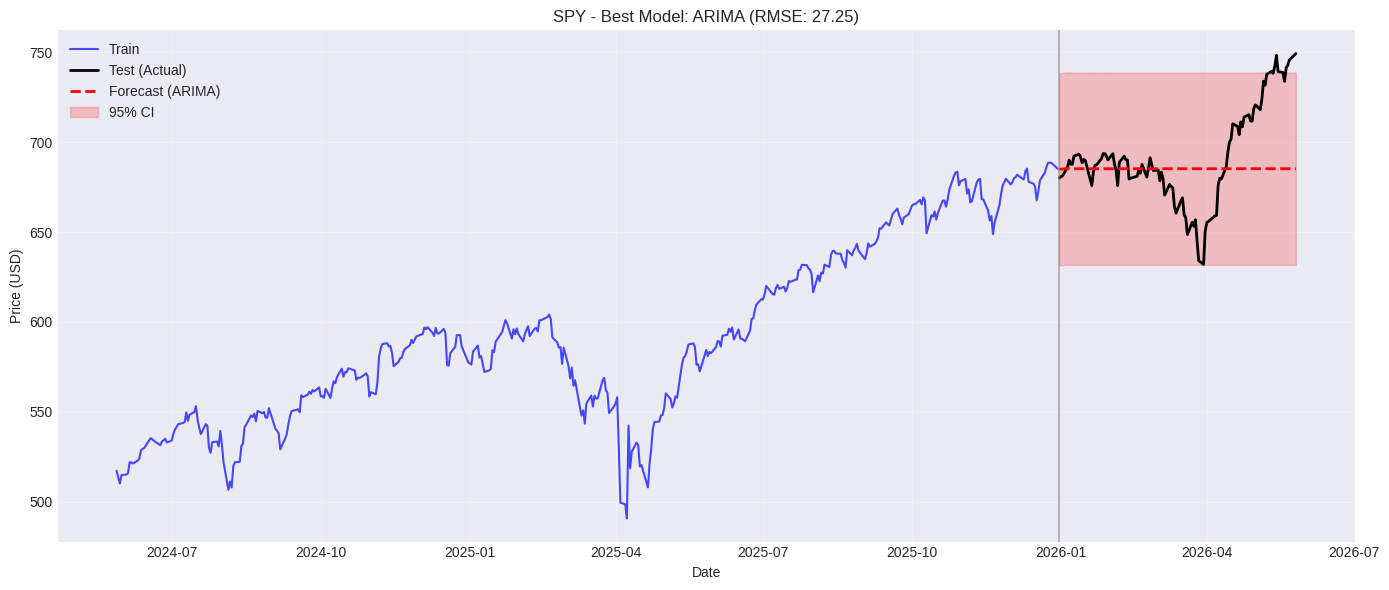

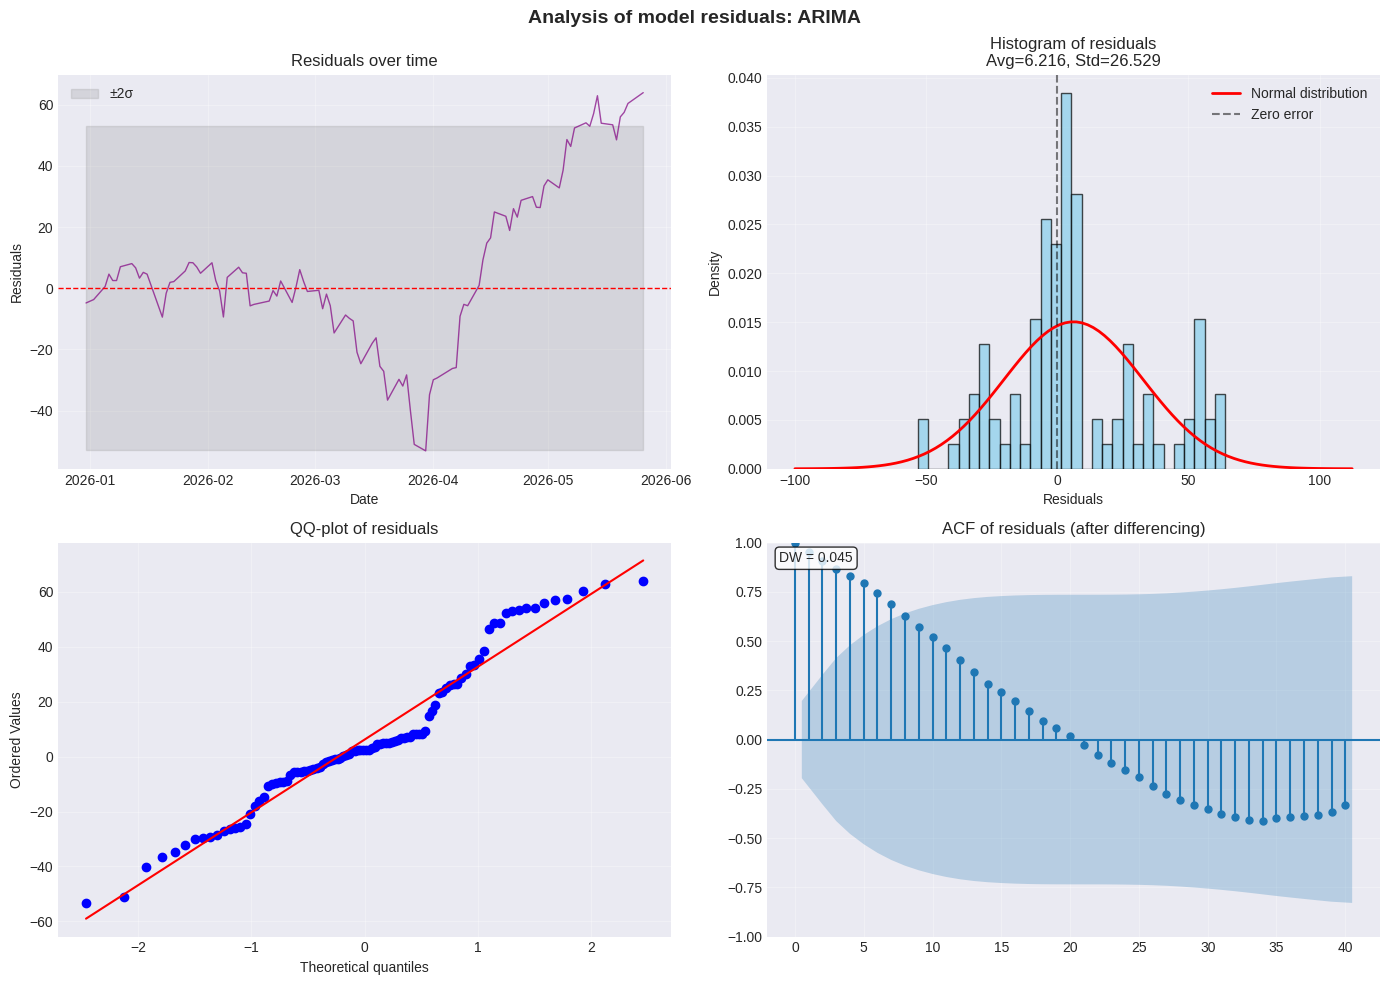

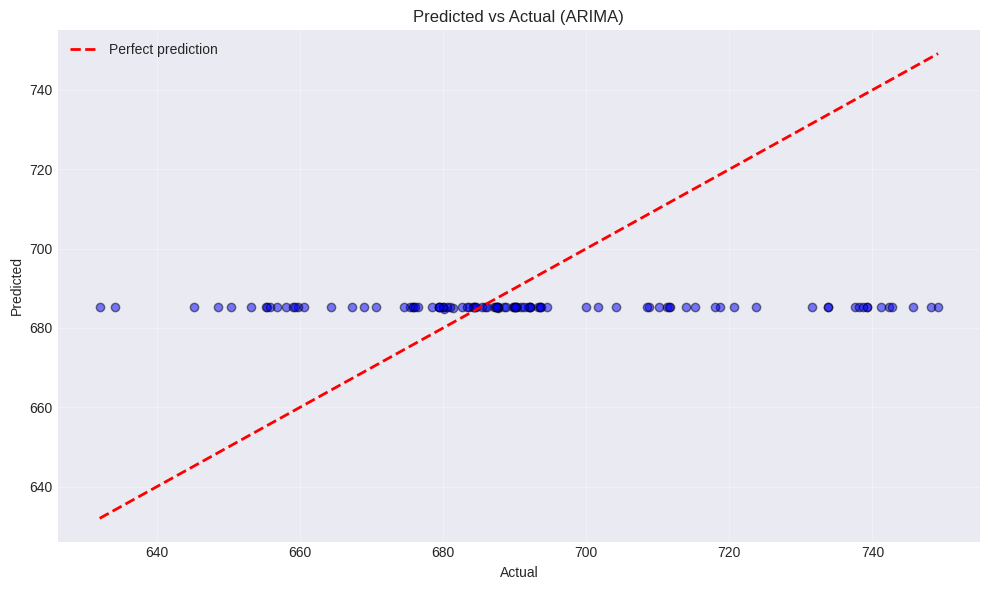

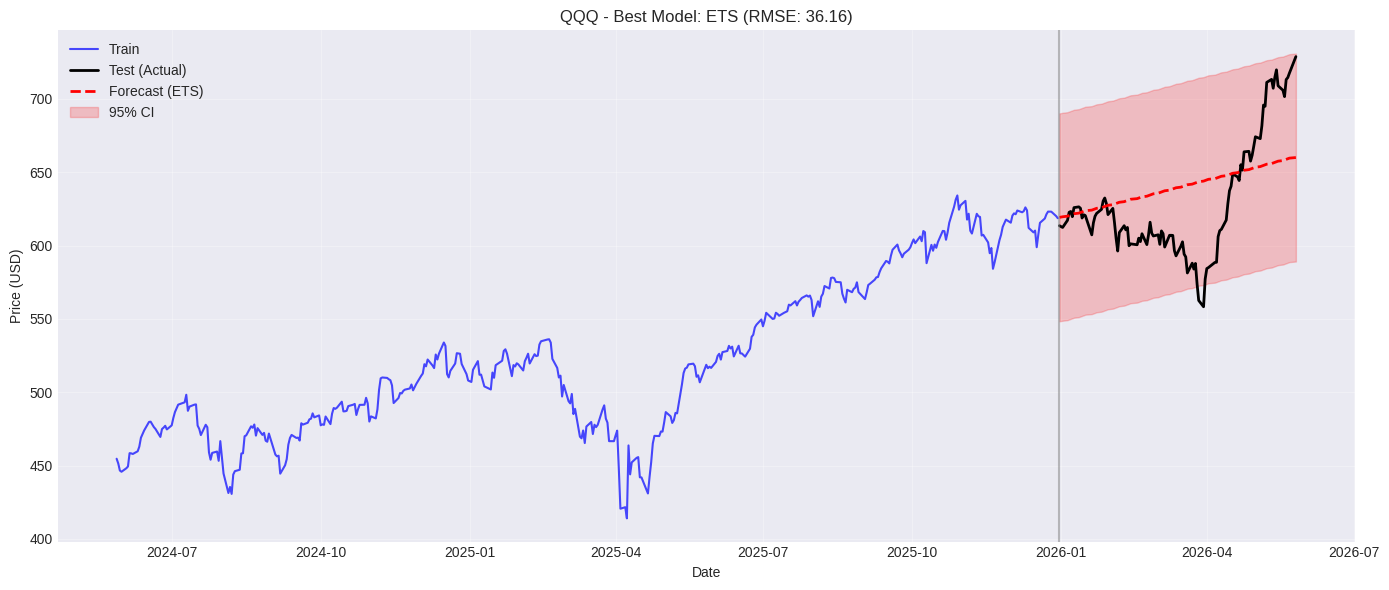

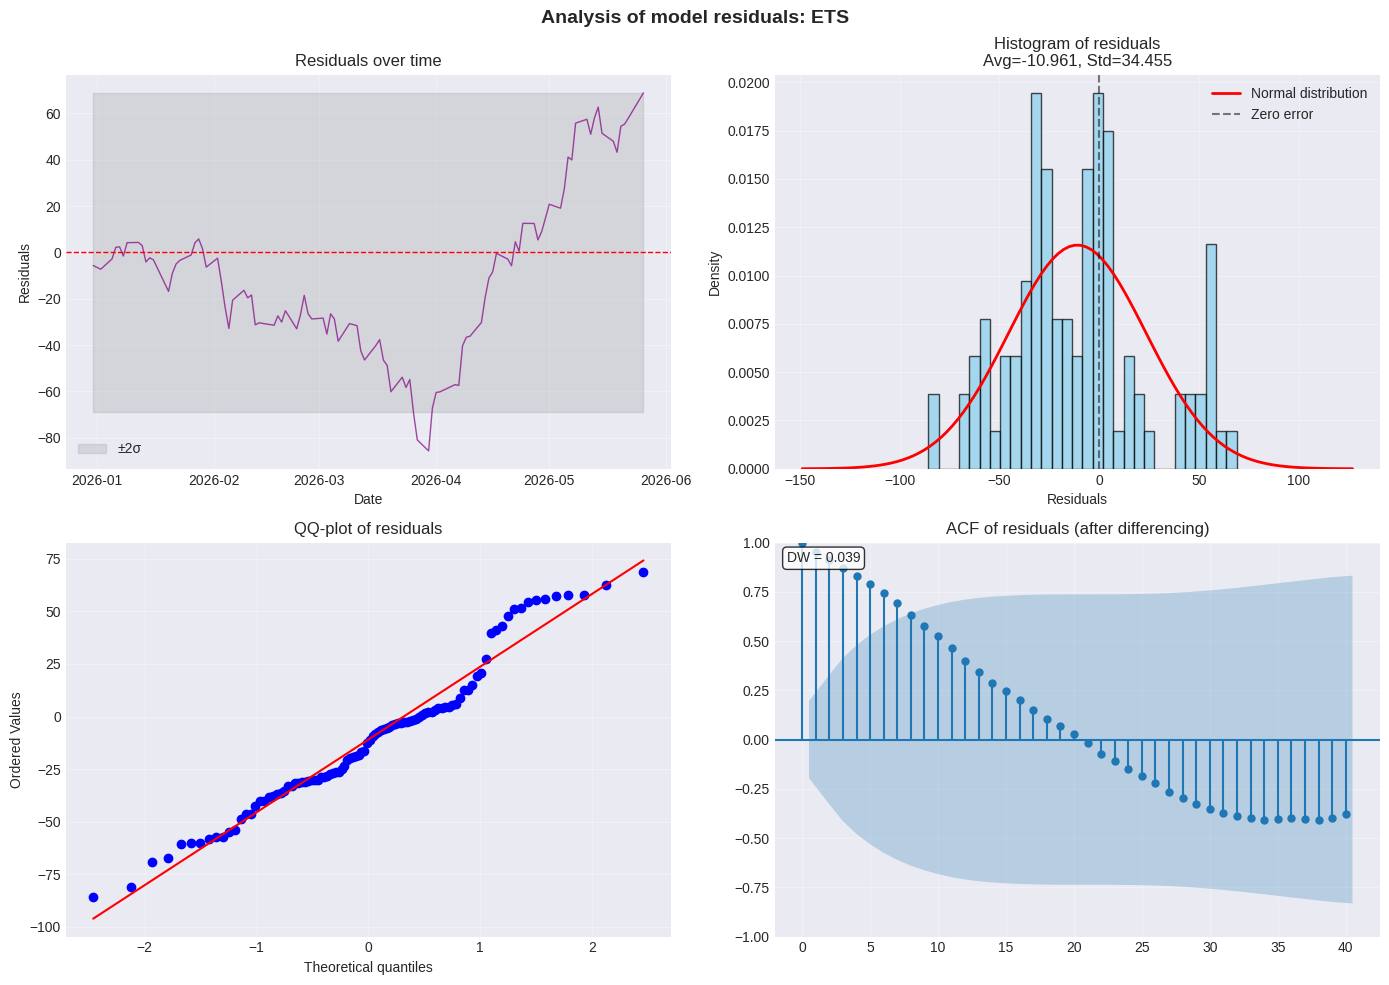

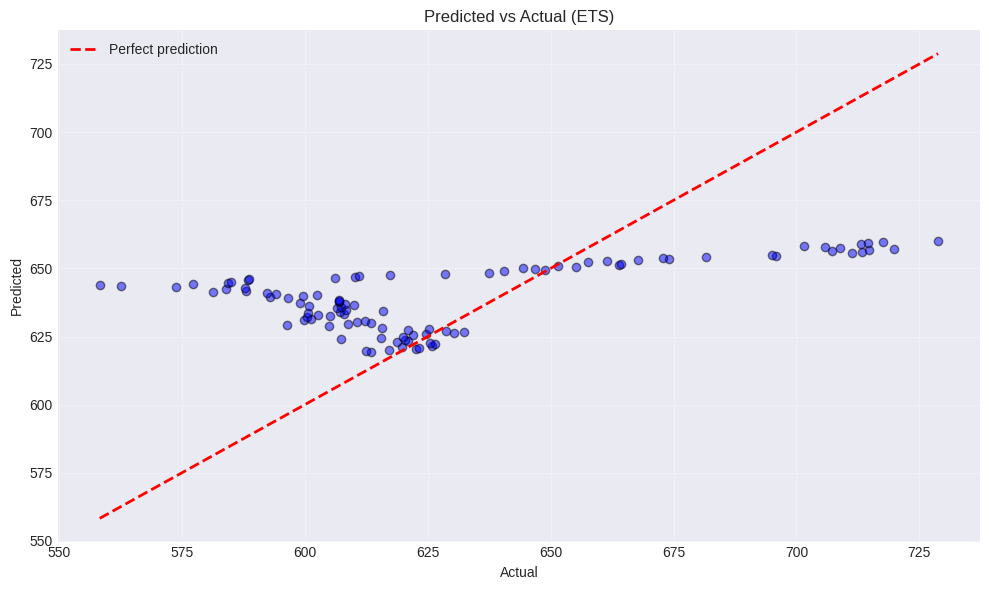

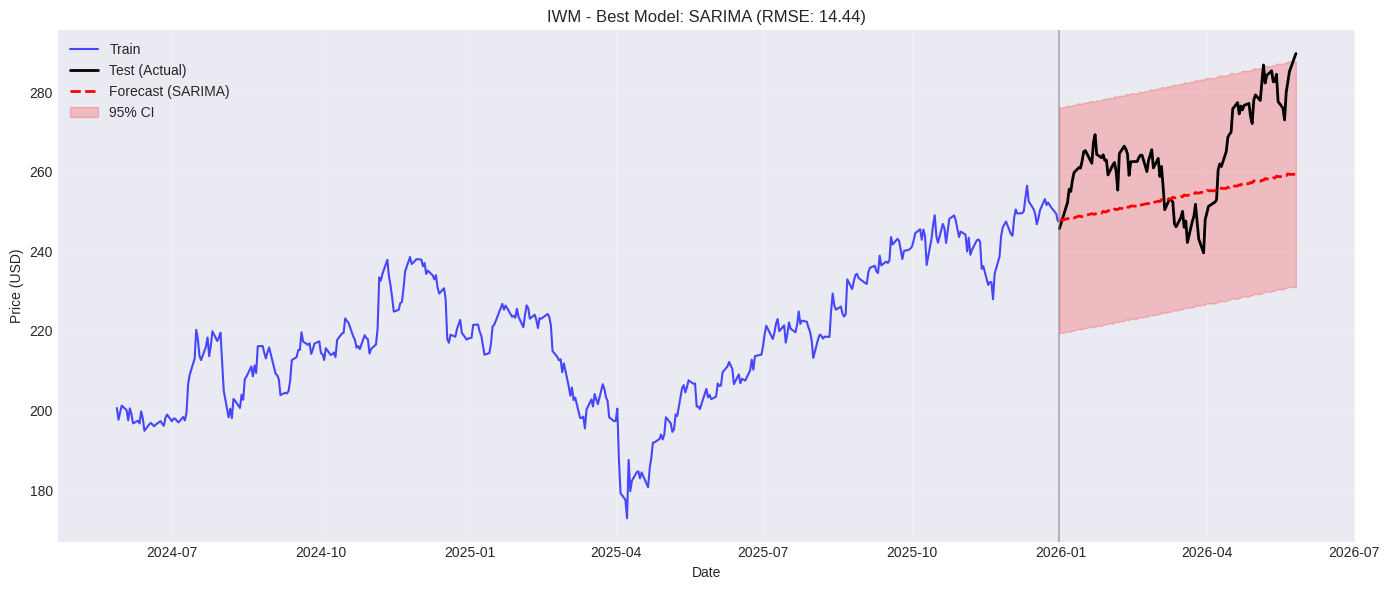

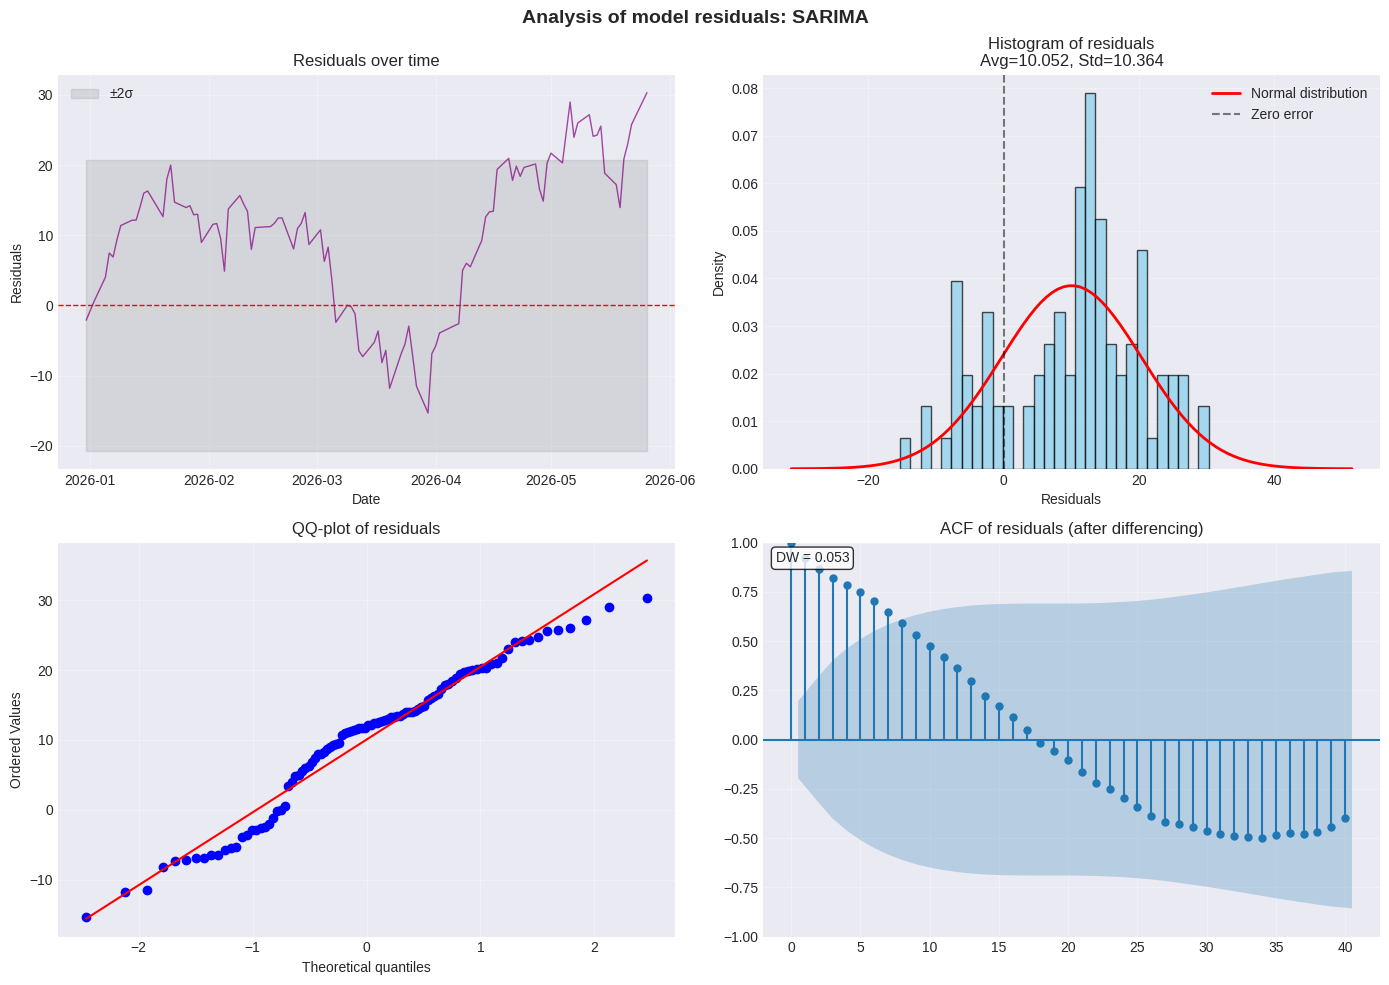

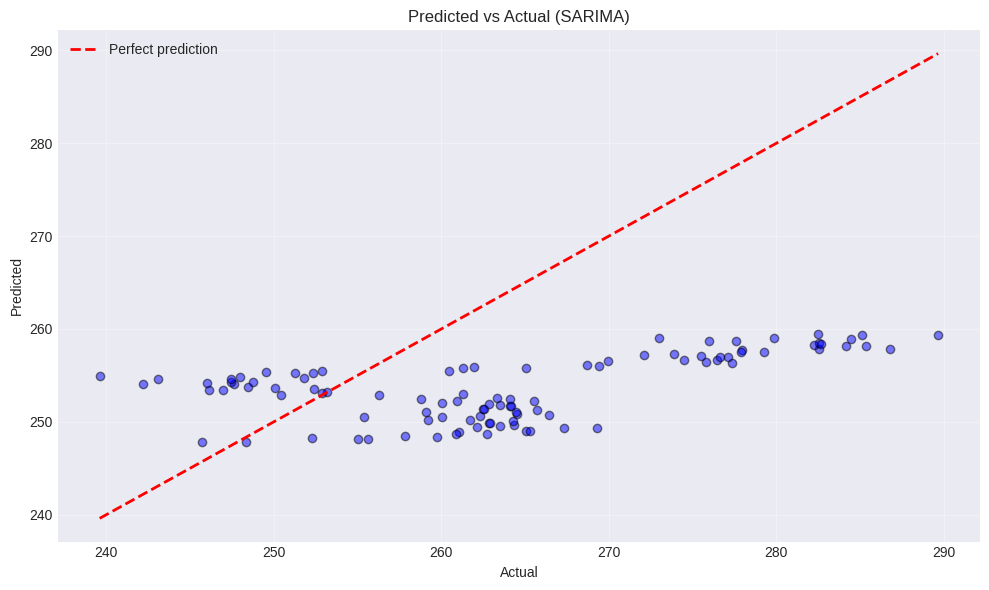

RESULTS:


,Ticker,Price,SMA 50/200,RSI,RSI Status,Signal
0,SPY,$749.17,BULL,70.8,Overbought,BUY
1,QQQ,$728.81,BULL,74.2,Overbought,BUY
2,IWM,$289.66,BULL,58.0,Neutral,BUY


The analysis is over!


In [44]:
# -*- coding: utf-8 -*-

# ETF Complete Technical Analysis

# ETF: RSI, MACD, Bollinger Bands, EMA, просадка, Sharpe ratio,
# forecasting with automatic selection of the best model(SARIMAX, LSTM, ETS, Naive and LSTM + ARIMA)

import os
import sys
import logging
from typing import Dict, List, Optional, Tuple, Union
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

try:
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy import stats
    from statsmodels.graphics.tsaplots import plot_acf
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    from sklearn.preprocessing import MinMaxScaler
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except ImportError as e:
    print(f"Library import error: {e}")
    sys.exit(1)

# logging.basicConfig(
#     level=logging.INFO,
#     format='%(asctime)s - %(levelname)s - %(message)s',
#     datefmt='%Y-%m-%d %H:%M:%S'
# )
# logger = logging.getLogger(__name__)

class Config:

    RSI_PERIOD = 14
    MACD_FAST = 12
    MACD_SLOW = 26
    MACD_SIGNAL = 9
    BB_WINDOW = 20
    BB_STD = 2
    EMA_PERIODS = [9, 12, 20, 26, 50, 200]
    SMA_SHORT = 50
    SMA_LONG = 200

    RISK_FREE_RATE = 0.02
    TRADING_DAYS_PER_YEAR = 252

    DEFAULT_LOOKBACK = 30
    TRAIN_TEST_SPLIT = 0.8
    LSTM_EPOCHS = 20
    LSTM_BATCH_SIZE = 8

    FIGURE_SIZE = (16, 12)
    DPI = 100


def safe_display(obj):
    try:
        from IPython.display import display
        display(obj)
    except (ImportError, NameError):
        print(obj)

def setup_matplotlib_style():
    try:
        if 'seaborn-v0_8-darkgrid' in plt.style.available:
            plt.style.use('seaborn-v0_8-darkgrid')
        elif 'seaborn-darkgrid' in plt.style.available:
            plt.style.use('seaborn-darkgrid')
        else:
            plt.style.use('ggplot')
    except Exception as e:
        print(f"The style is not set : {e}. The default style is used")

setup_matplotlib_style()

class TechnicalIndicators:

    @staticmethod
    # to calculate RSI (Relative Strength Index)
    def rsi(df: pd.DataFrame, period: int = Config.RSI_PERIOD) -> pd.DataFrame:
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss.replace(0, np.nan)
        df['RSI'] = 100 - (100 / (1 + rs))
        return df

    @staticmethod
    # to calculate MACD (Moving Average Convergence Divergence)
    def macd(df: pd.DataFrame,
             fast: int = Config.MACD_FAST,
             slow: int = Config.MACD_SLOW,
             signal: int = Config.MACD_SIGNAL) -> pd.DataFrame:
        df['EMA_fast'] = df['Close'].ewm(span=fast, adjust=False).mean()
        df['EMA_slow'] = df['Close'].ewm(span=slow, adjust=False).mean()
        df['MACD_line'] = df['EMA_fast'] - df['EMA_slow']
        df['MACD_signal'] = df['MACD_line'].ewm(span=signal, adjust=False).mean()
        df['MACD_histogram'] = df['MACD_line'] - df['MACD_signal']
        return df

    @staticmethod
    # to calculate bollinger bands
    def bollinger_bands(df: pd.DataFrame,
                       window: int = Config.BB_WINDOW,
                       num_std: int = Config.BB_STD) -> pd.DataFrame:
        rolling_mean = df['Close'].rolling(window=window).mean()
        rolling_std = df['Close'].rolling(window=window).std()
        df['BB_middle'] = rolling_mean
        df['BB_upper'] = rolling_mean + (rolling_std * num_std)
        df['BB_lower'] = rolling_mean - (rolling_std * num_std)
        return df

    @staticmethod
    # to calculate ema
    def ema(df: pd.DataFrame, periods: List[int] = None) -> pd.DataFrame:
        if periods is None:
            periods = Config.EMA_PERIODS
        for period in periods:
            df[f'EMA_{period}'] = df['Close'].ewm(span=period, adjust=False).mean()
        return df

    @staticmethod
    # to calculate sma crossover
    def sma_crossover(df: pd.DataFrame,
                     short: int = Config.SMA_SHORT,
                     long: int = Config.SMA_LONG) -> pd.DataFrame:
        df['SMA_50'] = df['Close'].rolling(window=short).mean()
        df['SMA_200'] = df['Close'].rolling(window=long).mean()
        df['Signal'] = 0
        df.loc[df['SMA_50'] > df['SMA_200'], 'Signal'] = 1
        df.loc[df['SMA_50'] < df['SMA_200'], 'Signal'] = -1
        df['Signal_Change'] = df['Signal'].diff()
        return df

    @staticmethod
    def apply_all(df: pd.DataFrame) -> pd.DataFrame:
        df = TechnicalIndicators.rsi(df)
        df = TechnicalIndicators.macd(df)
        df = TechnicalIndicators.bollinger_bands(df)
        df = TechnicalIndicators.ema(df)
        df = TechnicalIndicators.sma_crossover(df)
        return df

class RiskMetrics:

    def __init__(self, df: pd.DataFrame, risk_free_rate: float = Config.RISK_FREE_RATE):
        self.df = df.copy()
        self.risk_free_rate = risk_free_rate
        self._calculate_returns()

    def _calculate_returns(self):
        self.df['Daily_Return'] = self.df['Close'].pct_change()
        self.df['Cumulative_Return'] = (1 + self.df['Daily_Return']).cumprod()

    def max_drawdown(self) -> float:
        cumulative_max = self.df['Cumulative_Return'].cummax()
        drawdown = (self.df['Cumulative_Return'] - cumulative_max) / cumulative_max
        return drawdown.min()

    def sharpe_ratio(self) -> float:
        avg_daily_return = self.df['Daily_Return'].mean()
        std_daily_return = self.df['Daily_Return'].std()
        annual_return = (1 + avg_daily_return) ** Config.TRADING_DAYS_PER_YEAR - 1
        annual_volatility = std_daily_return * np.sqrt(Config.TRADING_DAYS_PER_YEAR)
        if annual_volatility == 0:
            return 0
        return (annual_return - self.risk_free_rate) / annual_volatility

    def volatility(self) -> float:
        return self.df['Daily_Return'].std() * np.sqrt(Config.TRADING_DAYS_PER_YEAR)

    def total_return(self) -> float:
        return (self.df['Close'].iloc[-1] / self.df['Close'].iloc[0] - 1) * 100

    def get_all_metrics(self) -> Dict[str, float]:
        return {
            'Total Return (%)': round(self.total_return(), 2),
            'Volatility (Annual %)': round(self.volatility() * 100, 2),
            'Max Drawdown (%)': round(self.max_drawdown() * 100, 2),
            'Sharpe Ratio': round(self.sharpe_ratio(), 3)
        }

class ETFDataLoader:

    def __init__(self, tickers: List[str], days_back: int = 730):
        self.tickers = tickers
        self.end_date = datetime.now()
        self.start_date = self.end_date - timedelta(days=days_back)
        self.data: Dict[str, Optional[pd.DataFrame]] = {}
        self.price_column = 'Close'

    def load_all(self) -> Dict[str, Optional[pd.DataFrame]]:
        print(f"Load data from {self.start_date.date()} to {self.end_date.date()}")

        for ticker in self.tickers:
            try:
                df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
                if not df.empty and 'Close' in df.columns:
                    self.data[ticker] = df
                    print(f"{ticker}: {len(df)} days")
                else:
                    print(f"{ticker}: the data is not loaded or the Close column is missing")
                    self.data[ticker] = None
            except Exception as e:
                print(f"Download error {ticker}: {e}")
                self.data[ticker] = None

        return self.data

class ETFVisualizer:

    @staticmethod
    def plot_complete_analysis(ticker: str, df: pd.DataFrame):
        if df is None or df.empty or 'Close' not in df.columns:
            print(f"No data {ticker}")
            return

        fig, axes = plt.subplots(4, 1, figsize=Config.FIGURE_SIZE, sharex=True)

        ax1 = axes[0]
        ax1.plot(df.index, df['Close'], label='Close', color='black', alpha=0.7)

        if 'EMA_20' in df.columns:
            ax1.plot(df.index, df['EMA_20'], label='EMA 20', color='blue', alpha=0.7, linewidth=1)
        if 'EMA_50' in df.columns:
            ax1.plot(df.index, df['EMA_50'], label='EMA 50', color='orange', alpha=0.7, linewidth=1)
        if 'SMA_200' in df.columns:
            ax1.plot(df.index, df['SMA_200'], label='SMA 200', color='red', alpha=0.7, linewidth=1)
        if 'BB_upper' in df.columns and 'BB_lower' in df.columns:
            # ax1.fill_between(df.index, df['BB_upper'], df['BB_lower'],
            #                alpha=0.2, color='gray', label='Bollinger Bands')
            ax1.fill_between(df.index.values,
                  df['BB_upper'].values.flatten(),
                  df['BB_lower'].values.flatten(),
                  alpha=0.2, color='gray', label='Bollinger Bands')

        ax1.set_ylabel('Price (USD)')
        ax1.set_title(f'{ticker} - Price & Technical Indicators')
        ax1.legend(loc='upper left', fontsize=8)
        ax1.grid(True, alpha=0.3)

        ax2 = axes[1]
        if 'RSI' in df.columns:
            ax2.plot(df.index, df['RSI'], label='RSI', color='purple', linewidth=1)
            ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
            ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
            ax2.fill_between(df.index, 70, df['RSI'], where=(df['RSI'] >= 70), color='red', alpha=0.3)
            ax2.fill_between(df.index, 30, df['RSI'], where=(df['RSI'] <= 30), color='green', alpha=0.3)
            ax2.set_ylabel('RSI')
            ax2.set_ylim(0, 100)
            ax2.set_title('RSI (Relative Strength Index)')
            ax2.legend(loc='upper left')
            ax2.grid(True, alpha=0.3)

        ax3 = axes[2]
        if 'MACD_line' in df.columns and 'MACD_signal' in df.columns:
            ax3.plot(df.index, df['MACD_line'], label='MACD Line', color='blue', linewidth=1)
            ax3.plot(df.index, df['MACD_signal'], label='Signal Line', color='red', linewidth=1)

            if 'MACD_histogram' in df.columns:
                colors = ['green' if val >= 0 else 'red' for val in df['MACD_histogram']]
                ax3.bar(df.index, df['MACD_histogram'], color=colors, alpha=0.5, label='Histogram')

            ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            ax3.set_ylabel('MACD')
            ax3.set_title('MACD (Moving Average Convergence Divergence)')
            ax3.legend(loc='upper left', fontsize=8)
            ax3.grid(True, alpha=0.3)

        ax4 = axes[3]
        if 'Signal' in df.columns:
            ax4.fill_between(df.index, df['Signal'], 0,
                           where=(df['Signal'] == 1), color='green', alpha=0.3, label='BUY Zone')
            ax4.fill_between(df.index, df['Signal'], 0,
                           where=(df['Signal'] == -1), color='red', alpha=0.3, label='SELL Zone')
            ax4.plot(df.index, df['Signal'], color='darkblue', linewidth=0.5, alpha=0.5)
            ax4.set_ylabel('Signal')
            ax4.set_xlabel('Date')
            ax4.set_title('50/200 DMA Strategy Signal (1 = BUY, -1 = SELL)')
            ax4.legend(loc='upper left')
            ax4.grid(True, alpha=0.3)
            ax4.set_ylim(-1.5, 1.5)

        plt.tight_layout()
        plt.show()

class MovingAverageComparison:

    def __init__(self, df: pd.DataFrame, periods: List[int] = None):
        if periods is None:
            periods = [20, 50, 200]
        self.df = df.copy()
        self.periods = periods
        self.results: Dict = {}

    def calculate_all(self) -> Dict:
        for period in self.periods:
            # Проверка достаточности данных
            if len(self.df) <= period:
                self.results[period] = {
                    'SMA_Smoothness': 'N/A (insufficient data)',
                    'EMA_Smoothness': 'N/A',
                    'Smoothness_Diff_%': 'N/A',
                    #'EMA_Faster': 'N/A',
                    'Data_Points': 0
                }
                continue

            sma_col = f'SMA_{period}'
            ema_col = f'EMA_{period}'

            if sma_col not in self.df.columns:
                self.df[sma_col] = self.df['Close'].rolling(window=period).mean()
            if ema_col not in self.df.columns:
                self.df[ema_col] = self.df['Close'].ewm(span=period, adjust=False).mean()

            sma_clean = self.df[sma_col].dropna()
            ema_clean = self.df[ema_col].dropna()

            if len(sma_clean) > 10 and len(ema_clean) > 10:
                sma_smoothness = sma_clean.diff().abs().mean()
                ema_smoothness = ema_clean.diff().abs().mean()

                if sma_smoothness != 0 and not np.isnan(sma_smoothness) and not np.isnan(ema_smoothness):
                    smoothness_diff = round((ema_smoothness - sma_smoothness) / sma_smoothness * 100, 2)
                    #ema_faster = "YES" if ema_smoothness > sma_smoothness else "NO"
                else:
                    smoothness_diff = 'N/A'
                    #ema_faster = 'N/A'

                self.results[period] = {
                    'SMA_Smoothness': round(sma_smoothness, 4),
                    'EMA_Smoothness': round(ema_smoothness, 4),
                    'Smoothness_Diff_%': smoothness_diff,
                    #'EMA_Faster': ema_faster,
                    'Data_Points': len(sma_clean)
                }
            else:
                self.results[period] = {
                    'SMA_Smoothness': f'N/A (точек: {len(sma_clean)})',
                    'EMA_Smoothness': 'N/A',
                    'Smoothness_Diff_%': 'N/A',
                    #'EMA_Faster': 'N/A',
                    'Data_Points': len(sma_clean)
                }

        return self.results

    def plot_comparison(self, ticker: str, period: int = 50):
        if period not in self.periods:
            print(f"period {period} is not in {self.periods}")
            return

        sma_col = f'SMA_{period}'
        ema_col = f'EMA_{period}'

        if sma_col not in self.df.columns:
            self.df[sma_col] = self.df['Close'].rolling(window=period).mean()
        if ema_col not in self.df.columns:
            self.df[ema_col] = self.df['Close'].ewm(span=period, adjust=False).mean()

        sma_clean = self.df[sma_col].dropna()
        ema_clean = self.df[ema_col].dropna()

        if len(sma_clean) == 0 or len(ema_clean) == 0:
            print(f"Not enough data to visualize the period {period}")
            return

        fig, ax = plt.subplots(figsize=(14, 6))

        days_to_show = min(252, len(self.df))

        ax.plot(self.df.index[-days_to_show:], self.df['Close'][-days_to_show:],
                label='Close Price', color='black', alpha=0.6, linewidth=1)
        ax.plot(sma_clean.index[-days_to_show:], sma_clean[-days_to_show:],
                label=f'SMA {period}', color='blue', linewidth=1.5)
        ax.plot(ema_clean.index[-days_to_show:], ema_clean[-days_to_show:],
                label=f'EMA {period}', color='red', linewidth=1.5, linestyle='--')

        ax.set_ylabel('Price (USD)')
        ax.set_title(f'{ticker} - SMA vs EMA Comparison (Period {period})')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def get_summary_table(self) -> pd.DataFrame:
        summary = []
        for period, metrics in self.results.items():
            summary.append({
                'Period': period,
                'SMA Smoothness': metrics.get('SMA_Smoothness', 'N/A'),
                'EMA Smoothness': metrics.get('EMA_Smoothness', 'N/A'),
                'Diff (%)': metrics.get('Smoothness_Diff_%', 'N/A'),
                #'EMA More Reactive?': metrics.get('EMA_Faster', 'N/A'),
                'Data Points': metrics.get('Data_Points', 0)
            })
        return pd.DataFrame(summary)

class BestModelForecaster:

    def __init__(self, df: pd.DataFrame, lookback: int = Config.DEFAULT_LOOKBACK):
        self.df = df.copy()
        self.lookback = lookback
        self.best_model_name: Optional[str] = None
        self.best_forecast: Optional[np.ndarray] = None
        self.best_metrics: Optional[Dict] = None
        self.train: Optional[pd.Series] = None
        self.test: Optional[pd.Series] = None
        self.models_results: Dict = {}
        self.lstm_model: Optional[Sequential] = None
        self.scaler: Optional[MinMaxScaler] = None

    def _validate_data(self) -> bool:
        if 'Close' not in self.df.columns:
            print("The 'Close' column is missing")
            return False

        if len(self.df) < 100:
            print(f" Insufficient data: {len(self.df)} days (min 100)")
            return False

        return True

    def _create_sequences(self, data: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        X, y = [], []
        for i in range(self.lookback, len(data)):
            X.append(data[i-self.lookback:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    def _naive_forecast(self, train_values: np.ndarray, test_values: np.ndarray) -> np.ndarray:
        return np.full(len(test_values), train_values[-1])

    def _ets_forecast(self, train_values: np.ndarray, test_values: np.ndarray) -> Optional[np.ndarray]:
        try:
            best_model = None
            best_aic = float('inf')
            combinations = [
                {'trend': 'add', 'seasonal': None, 'damped_trend': False},
                {'trend': 'add', 'seasonal': None, 'damped_trend': True},
                {'trend': 'mul', 'seasonal': None, 'damped_trend': False},
                {'trend': 'add', 'seasonal': 'add', 'damped_trend': False},
                {'trend': 'add', 'seasonal': 'mul', 'damped_trend': False},
            ]

            for params in combinations:
                try:
                    model = ExponentialSmoothing(
                        train_values,
                        trend=params['trend'],
                        seasonal=params['seasonal'],
                        damped_trend=params['damped_trend'],
                        initialization_method='estimated'
                    ).fit()
                    if model.aic < best_aic:
                        best_aic = model.aic
                        best_model = model
                except:
                    continue
            if best_model:
                forecast = best_model.forecast(len(test_values))
                return forecast

            model = ExponentialSmoothing(train_values, trend='add', seasonal=None).fit()
            return model.forecast(len(test_values))
        except Exception as e:
            print(f"ETS error: {e}")
            return None

    def _difference_series(self, series: np.ndarray, order: int = 1) -> np.ndarray:
        diff_series = np.diff(series, n=order)
        return diff_series

    def _inverse_difference(self, diff_series: np.ndarray, last_values: np.ndarray, order: int = 1) -> np.ndarray:
        result = np.zeros(len(diff_series) + order)
        result[:order] = last_values[-order:]
        for i in range(order, len(result)):
            result[i] = result[i-1] + diff_series[i-order]
        return result

    def _arima_forecast(self, train_values: np.ndarray, test_values: np.ndarray) -> Optional[np.ndarray]:
        try:
            best_aic = float('inf')
            best_order = None

            for p in [0, 1, 2, 3]:
                for d in [1, 2]:
                    for q in [0, 1, 2]:
                        try:
                            model = ARIMA(train_values, order=(p, d, q))
                            fitted = model.fit()
                            if fitted.aic < best_aic:
                                best_aic = fitted.aic
                                best_order = (p, d, q)
                        except:
                            continue

            if best_order:
                print(f"ARIMA: {best_order}")
                model = ARIMA(train_values, order=best_order)
                fitted = model.fit()
                return fitted.forecast(len(test_values))

            return None
        except Exception as e:
            print(f"ARIMA error: {e}")
            return None

    def _sarima_forecast(self, train_values: np.ndarray, test_values: np.ndarray) -> Optional[np.ndarray]:
        try:
            model = SARIMAX(train_values, order=(1,1,1), seasonal_order=(0,1,1,5))
            print(f"SARIMA: order=(1,1,1), seasonal_order=(0,1,1,5)")
            fitted = model.fit(disp=False)
            return fitted.forecast(len(test_values))
        except Exception as e:
            print(f"SARIMA error: {e}")
            return None

    def _auto_sarima_forecast(self, train_values: np.ndarray, test_values: np.ndarray) -> Optional[np.ndarray]:

        try:
            if len(train_values) < 50:
                print(f"Auto-SARIMA: insufficient training data ({len(train_values)} points)")
                return None

            import itertools
            from statsmodels.stats.stattools import durbin_watson
            from statsmodels.stats.diagnostic import acorr_ljungbox

            p_range = range(0, 3)
            d_range = [1, 2]
            q_range = range(0, 3)

            P_range = range(0, 2)
            D_range = [1]
            Q_range = range(0, 2)
            s = 5

            best_aic = float('inf')
            best_bic = float('inf')
            best_order = None
            best_seasonal_order = None
            best_model = None
            best_dw = 0
            best_lb_pvalue = 0

            results = []
            total_combinations = len(p_range) * len(q_range) * len(P_range) * len(Q_range)
            counter = 0

            for p in p_range:
                for q in q_range:
                    for P in P_range:
                        for Q in Q_range:
                            counter += 1

                            try:
                                order = (p, 1, q)
                                seasonal_order = (P, 1, Q, s)

                                if p == 0 and q == 0 and P == 0 and Q == 0:
                                    continue

                                model = SARIMAX(
                                    train_values,
                                    order=order,
                                    seasonal_order=seasonal_order,
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                )

                                fitted = model.fit(disp=False, maxiter=100)

                                residuals = fitted.resid
                                dw = durbin_watson(residuals)

                                lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
                                lb_pvalue = lb_test['lb_pvalue'].iloc[0]

                                autocorr_penalty = abs(dw - 2) * 100
                                quality_score = fitted.aic + autocorr_penalty

                                result = {
                                    'order': order,
                                    'seasonal_order': seasonal_order,
                                    'aic': fitted.aic,
                                    'bic': fitted.bic,
                                    'dw': dw,
                                    'lb_pvalue': lb_pvalue,
                                    'quality_score': quality_score
                                }
                                results.append(result)

                                if quality_score < best_aic + abs(best_dw - 2) * 100:
                                    best_aic = fitted.aic
                                    best_bic = fitted.bic
                                    best_order = order
                                    best_seasonal_order = seasonal_order
                                    best_model = fitted
                                    best_dw = dw
                                    best_lb_pvalue = lb_pvalue
                                    print(f"SARIMA{order}x{seasonal_order}: AIC={fitted.aic:.1f}, DW={dw:.3f}, LB-p={lb_pvalue:.4f}")

                            except Exception as e:
                                continue

            if best_model is not None:
                print(f"\nBEST AUTO-SARIMA FOUND:")
                print(f"Order: {best_order}")
                print(f"Seasonal Order: {best_seasonal_order}")
                print(f"AIC: {best_aic:.1f}")
                print(f"Durbin-Watson: {best_dw:.3f}")
                print(f"Ljung-Box p-value: {best_lb_pvalue:.4f}")

                if best_dw < 1.5:
                    print(f"Still has positive autocorrelation (DW={best_dw:.3f})")
                    print(f"Try increasing AR order (p) or adding more differencing")
                elif best_dw > 2.5:
                    print(f"Still has negative autocorrelation (DW={best_dw:.3f})")
                    print(f"Try increasing MA order (q)")
                else:
                    print(f"Autocorrelation successfully removed!")
                forecast = best_model.forecast(len(test_values))

                self.auto_sarima_model = best_model
                self.auto_sarima_order = best_order
                self.auto_sarima_seasonal_order = best_seasonal_order

                return forecast

            print("No optimal model found, using default SARIMA(1,1,1)x(0,1,1,5)")
            model = SARIMAX(train_values, order=(1,1,1), seasonal_order=(0,1,1,5))
            fitted = model.fit(disp=False)
            return fitted.forecast(len(test_values))

        except Exception as e:
            print(f"Auto-SARIMA error: {e}")
            return None

    def _lstm_forecast(self, train_values: np.ndarray, test_values: np.ndarray) -> Optional[np.ndarray]:
        try:
            if len(train_values) < self.lookback + 20:
                print(f"LSTM: not enough data for training({len(train_values)} points)")
                return None

            train_returns = np.log(train_values[1:] / train_values[:-1])
            train_returns = np.nan_to_num(train_returns, nan=0.0, posinf=0.0, neginf=0.0)

            self.scaler = MinMaxScaler(feature_range=(-1, 1))
            train_scaled = self.scaler.fit_transform(train_returns.reshape(-1, 1))

            X_train, y_train = self._create_sequences(train_scaled)

            if len(X_train) < 20:
                print("LSTM: not enough sequences for training")
                return None

            self.lstm_model = Sequential([
                LSTM(32, return_sequences=False, input_shape=(self.lookback, 1)),
                Dropout(0.2),
                Dense(1, activation='tanh')
            ])

            self.lstm_model.compile(optimizer='adam', loss='mse')

            self.lstm_model.fit(
                X_train, y_train,
                epochs=Config.LSTM_EPOCHS,
                batch_size=Config.LSTM_BATCH_SIZE,
                verbose=0
            )

            predictions = []
            current_seq = train_scaled[-self.lookback:].copy()
            current_price = train_values[-1]

            for _ in range(len(test_values)):
                pred_return = self.lstm_model.predict(
                    current_seq.reshape(1, self.lookback, 1),
                    verbose=0
                )[0, 0]

                pred_return = np.clip(pred_return, -0.1, 0.1)

                next_price = current_price * np.exp(
                    self.scaler.inverse_transform([[pred_return]])[0, 0]
                )
                predictions.append(next_price)

                current_seq = np.roll(current_seq, -1, axis=0)
                current_seq[-1] = pred_return
                current_price = next_price

            return np.array(predictions)

        except Exception as e:
            print(f"LSTM error: {e}")
            return None

    def _lstm_arima_hybrid(self, train_values: np.ndarray, test_values: np.ndarray) -> Optional[np.ndarray]:
        try:
            model = ARIMA(train_values, order=(1,1,1))
            fitted = model.fit()
            arima_pred = fitted.forecast(len(test_values))

            fitted_values = fitted.fittedvalues
            fitted_values = fitted_values[~np.isnan(fitted_values)]

            min_len = min(len(train_values), len(fitted_values))
            aligned_train = train_values[-min_len:]
            aligned_fitted = fitted_values[-min_len:]

            residuals = aligned_train - aligned_fitted

            if len(residuals) < self.lookback + 20:
                print("Hybrid: insufficient data for the LSTM part")
                return arima_pred  # only ARIMA

            scaler = MinMaxScaler(feature_range=(-1, 1))
            residuals_scaled = scaler.fit_transform(residuals.reshape(-1, 1))

            X, y = self._create_sequences(residuals_scaled)

            if len(X) < 20:
                return arima_pred
            model_lstm = Sequential([
                LSTM(32, input_shape=(self.lookback, 1)),
                Dropout(0.2),
                Dense(1, activation='tanh')
            ])

            model_lstm.compile(optimizer='adam', loss='mse')
            model_lstm.fit(X, y, epochs=15, batch_size=8, verbose=0)

            preds = []
            seq = residuals_scaled[-self.lookback:].copy()

            for _ in range(len(test_values)):
                pred = model_lstm.predict(seq.reshape(1, self.lookback, 1), verbose=0)[0, 0]
                pred = np.clip(pred, -1, 1)  # Stabilization
                preds.append(pred)
                seq = np.roll(seq, -1, axis=0)
                seq[-1] = pred

            preds = np.array(preds).reshape(-1, 1)
            residuals_pred = scaler.inverse_transform(preds).flatten()

            final_forecast = arima_pred + residuals_pred

            return final_forecast

        except Exception as e:
            print(f"Hybrid error: {e}")
            return None

    def fit(self, train_size: float = Config.TRAIN_TEST_SPLIT, use_differencing: bool = False) -> Optional[Dict]:

        if not self._validate_data():
            return None

        close_series = self.df['Close'].dropna()
        split_idx = int(len(close_series) * train_size)

        train_values = close_series.values[:split_idx]
        test_values = close_series.values[split_idx:]
        print("use_differencing",use_differencing)
        test_values_original = test_values.copy()
        if use_differencing and False: #SARIMA/ARIMA already have built-in differentiation (d=1)
            self.last_train_value = train_values[-1]
            train_values = self._difference_series(train_values, order=1)
            #test_values_original = test_values.copy()
            test_values = test_values[1:] - test_values[:-1]


        self.train = close_series[:split_idx]
        self.test = close_series[split_idx:]

        print(f"Train: {len(train_values)} days, Test: {len(test_values)} days")
        print(f"Original test length: {len(test_values_original)} days")
        #avg_price = self.df['Close'].mean().iloc[0]
        avg_price = float(np.mean(self.df['Close'].values))
        if avg_price > 300:
            models = {
                'Naive': self._naive_forecast,
                'ETS': self._ets_forecast,
                'ARIMA': self._arima_forecast,
                'SARIMA': self._sarima_forecast,
                'Auto-SARIMA': self._auto_sarima_forecast
                }
                ## LSTM and Hybrid are disabled: if the prices are too high, an overflow may occur during the reverse conversion.
            print(f"Avg price {avg_price:.0f} > 300, LSTM and Hybrid disabled for stability")
        else:
            models = {
                'Naive': self._naive_forecast,
                'ETS': self._ets_forecast,
                'ARIMA': self._arima_forecast,
                'SARIMA': self._sarima_forecast,
                'Auto-SARIMA': self._auto_sarima_forecast,
                'LSTM': self._lstm_forecast,
                'Hybrid_LSTM_ARIMA': self._lstm_arima_hybrid
                }
            #,
            #'Hybrid_LSTM_ARIMA': self._lstm_arima_hybrid
        for name, model_func in models.items():
            print(f"Testing {name}")
            try:
                forecast = model_func(train_values, test_values)

                if forecast is not None and len(forecast) == len(test_values):
                    if use_differencing:
                        full_forecast = self._inverse_difference(
                            forecast, np.array([train_values[-1]]), order=1)
                        forecast_original = full_forecast[-len(test_values_original):]
                    else:
                        forecast_original = forecast
                    min_len = min(len(test_values_original), len(forecast_original))
                    test_aligned = test_values_original[:min_len]
                    forecast_aligned = forecast_original[:min_len]

                    rmse = np.sqrt(mean_squared_error(test_aligned, forecast_aligned))
                    mae = mean_absolute_error(test_aligned, forecast_aligned)
                    mape = np.mean(np.abs((test_aligned - forecast_aligned) / test_aligned)) * 100
                    numerator = np.sqrt(np.mean((test_aligned - forecast_aligned)**2))
                    denominator = np.sqrt(np.mean(test_aligned**2)) + np.sqrt(np.mean(forecast_aligned**2))
                    theil_u = numerator / denominator if denominator != 0 else 1.0
                    self.models_results[name] = {
                        'pred': forecast_aligned,
                        'rmse': rmse,
                        'mae': mae,
                        'mape': mape,
                        'theil_u': theil_u
                    }
                    print(f" RMSE: {rmse:.2f}, MAPE: {mape:.2f}%, Theil's U: {theil_u:.4f}")
                else:
                    print(f"{name}: the forecast is None or the wrong length(got {len(forecast) if forecast is not None else 'None'}, expected {len(test_values)})")
            except Exception as e:
                print(f" {name} error: {e}")

        if self.models_results:
            best_model = min(self.models_results.items(), key=lambda x: x[1]['rmse'])
            self.best_model_name = best_model[0]
            self.best_forecast = best_model[1]['pred']

            if hasattr(self.best_forecast, 'flatten'):
                self.best_forecast = self.best_forecast.flatten()

            self.best_metrics = {
                'RMSE': best_model[1]['rmse'],
                'MAE': best_model[1]['mae'],
                'MAPE (%)': best_model[1]['mape'],
                "Theils U": best_model[1]['theil_u'],
                'Model Type': self.best_model_name
            }
            test_flat = self.test.values[:len(self.best_forecast)].flatten()
            forecast_flat = self.best_forecast.flatten()
            residuals = test_flat - forecast_flat
            residuals = np.array(residuals).flatten()
            self.autocorr_stats = self.check_autocorrelation(residuals)
            self.residuals_stats = self._calculate_residuals_stats(residuals)
            print(f"AUTOCORRELATION ANALYSIS (after differencing)")
            print(f"Durbin-Watson: {self.autocorr_stats['durbin_watson']:.3f}")
            if self.autocorr_stats['durbin_watson'] < 1.5:
                print(f"Positive autocorrelation - differencing helped but not eliminated")
            elif self.autocorr_stats['durbin_watson'] > 2.5:
                print(f"Negative autocorrelation detected")
            else:
                print(f"Autocorrelation successfully removed!")
            print(f"\n The best model: {self.best_model_name}")
            #print(f"   RMSE: {self.best_metrics['RMSE']:.2f}")
            #print(f"   MAPE: {self.best_metrics['MAPE (%)']:.2f}%")
            self._print_residuals_stats(self.residuals_stats)
        else:
            print("\n Could not train any models")
            self.best_metrics = None
            return None

        return self.best_metrics

    def _calculate_residuals_stats(self, residuals: np.ndarray) -> Dict:
        if hasattr(residuals, 'flatten'):
            residuals = residuals.flatten()
        if len(residuals.shape) > 1:
            residuals = residuals.reshape(-1)
        mean_res = np.mean(residuals)
        std_res = np.std(residuals)
        skewness = pd.Series(residuals).skew()
        kurtosis = pd.Series(residuals).kurtosis()

        ci_lower = mean_res - 1.96 * std_res
        ci_upper = mean_res + 1.96 * std_res

        ks_stat, ks_pvalue = stats.kstest(residuals, 'norm', args=(mean_res, std_res)) #Kolmogorov-Smirnov

        if len(residuals) < 5000:
            shapiro_stat, shapiro_pvalue = stats.shapiro(residuals) #Shapiro–Wilk test
        else:
            shapiro_stat, shapiro_pvalue = (None, None)

        from statsmodels.stats.stattools import durbin_watson #Durbin-Watson
        dw_stat = durbin_watson(residuals)

        try:
            from statsmodels.stats.diagnostic import het_breuschpagan #Breusch-Pagan
            x = np.arange(len(residuals)).reshape(-1, 1)
            bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, x)
        except:
            bp_stat, bp_pvalue = (None, None)
        mse = np.mean(residuals ** 2)
        mae_res = np.mean(np.abs(residuals))
        max_error = np.max(np.abs(residuals))

        return {
            'mean': mean_res,
            'std': std_res,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'ks_stat': ks_stat,
            'ks_pvalue': ks_pvalue,
            'shapiro_stat': shapiro_stat,
            'shapiro_pvalue': shapiro_pvalue,
            'dw_stat': dw_stat,
            'bp_stat': bp_stat,
            'bp_pvalue': bp_pvalue,
            'mse': mse,
            'mae_res': mae_res,
            'max_error': max_error,
            'residuals': residuals
        }

    def check_autocorrelation(self, residuals: np.ndarray) -> Dict:
        from statsmodels.stats.stattools import durbin_watson
        from statsmodels.graphics.tsaplots import plot_acf

        dw_stat = durbin_watson(residuals)

        from statsmodels.stats.diagnostic import acorr_ljungbox
        lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)

        return {
            'durbin_watson': dw_stat,
            'ljung_box_pvalue_10': lb_test['lb_pvalue'].iloc[0] if len(lb_test) > 0 else None,
            'ljung_box_pvalue_20': lb_test['lb_pvalue'].iloc[1] if len(lb_test) > 1 else None,
            'autocorrelation_present': dw_stat < 1.5 or dw_stat > 2.5
        }

    def _print_residuals_stats(self, stats_dict: Dict):

        print(f"\nKey metrics:")
        print(f"RMSE: {self.best_metrics['RMSE']:.3f}")
        print(f"MAE: {self.best_metrics['MAE']:.3f}")
        print(f"MAPE: {self.best_metrics['MAPE (%)']:.3f}%")
        print(f"Theil's U: {self.best_metrics['Theils U']:.4f}")

        print(f"\nResidual statistics:")
        print(f"Mean error (bias): {stats_dict['mean']:.3f}")
        print(f"Standard deviation: {stats_dict['std']:.3f}")
        print(f"Skewness: {stats_dict['skewness']:.3f}")
        print(f"Kurtosis: {stats_dict['kurtosis']:.3f}")
        print(f"MSE: {stats_dict['mse']:.3f}")
        print(f"MAE (residuals): {stats_dict['mae_res']:.3f}")
        print(f"Maximum error: {stats_dict['max_error']:.3f}")
        print(f"95% confidence interval: [{stats_dict['ci_lower']:.3f}, {stats_dict['ci_upper']:.3f}]")

        if hasattr(self, 'autocorr_stats'):
            print(f"\nAutocorrelation analysis (after differencing):")
            print(f"Durbin-Watson: {self.autocorr_stats['durbin_watson']:.3f}")
            if self.autocorr_stats['ljung_box_pvalue_10']:
                print(f"Ljung-Box p-value (lags=10): {self.autocorr_stats['ljung_box_pvalue_10']:.4f}")
            if self.autocorr_stats['ljung_box_pvalue_20']:
                print(f"Ljung-Box p-value (lags=20): {self.autocorr_stats['ljung_box_pvalue_20']:.4f}")

            if self.autocorr_stats['durbin_watson'] < 1.5:
                print(f"Positive autocorrelation detected (DW < 1.5)")
            elif self.autocorr_stats['durbin_watson'] > 2.5:
                print(f"Negative autocorrelation detected (DW > 2.5)")
            else:
                print(f"No significant autocorrelation (DW in [1.5, 2.5])")

            if self.autocorr_stats.get('ljung_box_pvalue_10', 1.0) < 0.05:
                print(f"Ljung-Box test suggests autocorrelation (p < 0.05)")
            else:
                print(f"Ljung-Box test: no significant autocorrelation")

        print(f"\nNormality test (Kolmogorov–Smirnov):")
        print(f"KS statistic: {stats_dict['ks_stat']:.4f}")
        print(f"P-value: {stats_dict['ks_pvalue']:.4f}")
        if stats_dict['ks_pvalue'] > 0.05:
            print(f"Residuals are normally distributed (p > 0.05)")
        else:
            print(f"Residuals are NOT normally distributed (p < 0.05)")

        if stats_dict['shapiro_stat'] is not None:
            print(f"\nShapiro-Wilk test:")
            print(f"Statistic: {stats_dict['shapiro_stat']:.4f}")
            print(f"P-value: {stats_dict['shapiro_pvalue']:.4f}")
            if stats_dict['shapiro_pvalue'] > 0.05:
                print(f"Residuals are normally distributed (p > 0.05)")
            else:
                print(f"Residuals are NOT normally distributed (p < 0.05)")

        print(f"\nAutocorrelation test (Durbin-Watson):")
        print(f"DW statistic: {stats_dict['dw_stat']:.3f}")
        if stats_dict['dw_stat'] < 1.5:
            print(f"Positive autocorrelation detected")
        elif stats_dict['dw_stat'] > 2.5:
            print(f"Negative autocorrelation detected")
        else:
            print(f"No significant autocorrelation")

        if stats_dict['bp_stat'] is not None:
            print(f"\nHeteroscedasticity test (Breusch-Pagan):")
            print(f"Statistic: {stats_dict['bp_stat']:.4f}")
            print(f"P-value: {stats_dict['bp_pvalue']:.4f}")
            if stats_dict['bp_pvalue'] > 0.05:
                print(f"Homoscedasticity (constant variance)")
            else:
                print(f"Heteroscedasticity detected (non-constant variance)")

    def plot_residuals_analysis(self):
        if not hasattr(self, 'residuals_stats'):
            print("fit()!!!")
            return
        residuals = self.residuals_stats['residuals']
        if hasattr(residuals, 'flatten'):
            residuals = residuals.flatten()
        if len(residuals.shape) > 1:
            residuals = residuals.reshape(-1)
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Analysis of model residuals: {self.best_model_name}', fontsize=14, fontweight='bold')

        ax1 = axes[0, 0]
        test_idx = self.test.index
        ax1.plot(test_idx, residuals, color='purple', alpha=0.7, linewidth=1)
        ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
        ax1.fill_between(test_idx, -self.residuals_stats['std']*2, self.residuals_stats['std']*2,
                         alpha=0.2, color='gray', label='±2σ')
        ax1.set_title('Residuals over time')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Residuals')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = axes[0, 1]
        n, bins, patches = ax2.hist(residuals, bins=30, density=True, alpha=0.7,
                                     color='skyblue', edgecolor='black')
        mu = self.residuals_stats['mean']
        sigma = self.residuals_stats['std']
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
        y = stats.norm.pdf(x, mu, sigma)
        ax2.plot(x, y, 'r-', linewidth=2, label='Normal distribution')
        ax2.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Zero error')
        ax2.set_title(f'Histogram of residuals\nAvg={mu:.3f}, Std={sigma:.3f}')
        ax2.set_xlabel('Residuals')
        ax2.set_ylabel('Density')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        ax3 = axes[1, 0]
        stats.probplot(residuals, dist="norm", plot=ax3)
        ax3.set_title('QQ-plot of residuals')
        ax3.grid(True, alpha=0.3)

        ax4 = axes[1, 1]
        try:
            from statsmodels.graphics.tsaplots import plot_acf
            max_lags = min(40, len(residuals) // 2)
            plot_acf(residuals, lags=max_lags, ax=ax4, alpha=0.05)
            ax4.set_title('ACF of residuals (after differencing)')
            ax4.grid(True, alpha=0.3)

            if hasattr(self, 'autocorr_stats'):
                dw = self.autocorr_stats['durbin_watson']
                ax4.text(0.02, 0.95, f'DW = {dw:.3f}', transform=ax4.transAxes,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        except Exception as e:
            ax4.text(0.5, 0.5, f'ACF plot error:\n{str(e)}',
                    ha='center', va='center', transform=ax4.transAxes)

        plt.tight_layout()
        plt.show()

        fig2, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(self.test.values, self.best_forecast, alpha=0.5, color='blue', edgecolors='black')

        min_val = min(np.min(self.test.values), np.min(self.best_forecast))
        max_val = max(np.max(self.test.values), np.max(self.best_forecast))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Predicted vs Actual ({self.best_model_name})')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def predict_future(self, steps: int = 10) -> Optional[np.ndarray]:

        if self.best_model_name is None:
            print("Train the model first (fit())")
            return None

        full_series = self.df['Close'].dropna().values

        print(f"Forecast for {steps} days ahead with the model {self.best_model_name}")

        try:
            if self.best_model_name == 'Naive':
                return np.full(steps, full_series[-1])

            elif self.best_model_name == 'ETS':
                model = ExponentialSmoothing(
                    full_series,
                    trend='add',
                    seasonal=None,
                    damped_trend=True
                ).fit()
                return model.forecast(steps)

            elif self.best_model_name == 'ARIMA':
                best_aic = float('inf')
                best_order = None

                for p in [0, 1, 2]:
                    for d in [1]:
                        for q in [0, 1, 2]:
                            try:
                                model = ARIMA(full_series, order=(p, d, q))
                                fitted = model.fit()
                                if fitted.aic < best_aic:
                                    best_aic = fitted.aic
                                    best_order = (p, d, q)
                            except:
                                continue

                if best_order:
                    model = ARIMA(full_series, order=best_order)
                    fitted = model.fit()
                    return fitted.forecast(steps)

                return np.full(steps, full_series[-1])

            elif self.best_model_name == 'SARIMA':
                model = SARIMAX(full_series, order=(1,1,1), seasonal_order=(0,1,1,5))
                fitted = model.fit(disp=False)
                return fitted.forecast(steps)

            elif self.best_model_name == 'LSTM':
                if self.lstm_model is not None and self.scaler is not None:
                    predictions = []
                    recent_data = full_series[-(self.lookback + 1):]
                    recent_returns = np.log(recent_data[1:] / recent_data[:-1])
                    recent_returns = np.nan_to_num(recent_returns, nan=0.0)

                    current_seq = self.scaler.transform(recent_returns.reshape(-1, 1))[-self.lookback:]
                    current_price = full_series[-1]

                    for _ in range(steps):
                        pred_return = self.lstm_model.predict(
                            current_seq.reshape(1, self.lookback, 1),
                            verbose=0
                        )[0, 0]

                        pred_return = np.clip(pred_return, -0.1, 0.1)

                        next_price = current_price * np.exp(
                            self.scaler.inverse_transform([[pred_return]])[0, 0]
                        )
                        predictions.append(next_price)

                        current_seq = np.roll(current_seq, -1, axis=0)
                        current_seq[-1] = pred_return
                        current_price = next_price

                    return np.array(predictions)
                else:
                    print("The LSTM model is not trained")
                    return np.full(steps, full_series[-1])

            elif self.best_model_name == 'Hybrid_LSTM_ARIMA':
                model = ARIMA(full_series, order=(1,1,1))
                fitted = model.fit()
                return fitted.forecast(steps)

            else:
                return np.full(steps, full_series[-1])

        except Exception as e:
            print(f"Forecasting error: {e}")
            return np.full(steps, full_series[-1])

    def plot_forecast(self, ticker: str):

        if self.best_forecast is None or self.test is None or self.train is None:
            print(f"There is no forecast for {ticker}")
            return

        fig, ax = plt.subplots(figsize=(14, 6))
        split_idx = len(self.train)

        ax.plot(self.df.index[:split_idx], self.train,
                label='Train', color='blue', alpha=0.7)

        test_idx = self.df.index[split_idx:split_idx + len(self.test)]
        ax.plot(test_idx, self.test,
                label='Test (Actual)', color='black', linewidth=2)

        forecast_idx = self.df.index[split_idx:split_idx + len(self.best_forecast)]
        ax.plot(forecast_idx, self.best_forecast,
                label=f'Forecast ({self.best_model_name})',
                color='red', linestyle='--', linewidth=2)

        if self.best_metrics:
            std = self.best_metrics['RMSE']
            lower_bound = self.best_forecast - 1.96 * std
            upper_bound = self.best_forecast + 1.96 * std
            lower_bound = np.array(lower_bound).flatten()
            upper_bound = np.array(upper_bound).flatten()
            ax.fill_between(forecast_idx,lower_bound, upper_bound,
                       alpha=0.2, color='red', label='95% CI')

        ax.axvline(x=self.df.index[split_idx], color='gray', linestyle='-', alpha=0.5)
        ax.set_title(f'{ticker} - Best Model: {self.best_model_name} (RMSE: {self.best_metrics["RMSE"]:.2f})')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price (USD)')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

class ETFAnalyzer:

    def __init__(self, tickers: List[str], days_back: int = 730):
        self.tickers = tickers
        self.days_back = days_back
        self.loader = ETFDataLoader(tickers, days_back)
        self.data: Dict[str, Optional[pd.DataFrame]] = {}
        self.results: Dict[str, Dict] = {}

    def run_analysis(self) -> Dict[str, Optional[pd.DataFrame]]:
        self.data = self.loader.load_all()
        for ticker, df in self.data.items():
            if df is not None and not df.empty and 'Close' in df.columns:
                try:
                    self.data[ticker] = TechnicalIndicators.apply_all(df)
                    print(f"The indicators for {ticker}")
                except Exception as e:
                    print(f"Error for {ticker}: {e}")

        for ticker, df in self.data.items():
            if df is not None and not df.empty and 'Close' in df.columns:
                try:
                    risk = RiskMetrics(df)
                    self.results[ticker] = risk.get_all_metrics()
                except Exception as e:
                    print(f"Risk metrics error for {ticker}: {e}")
                    self.results[ticker] = {}

        print("\nThe analysis is over!")
        return self.data

    def get_current_status(self, ticker: str) -> Optional[Dict]:
        df = self.data.get(ticker)
        if df is None or df.empty or 'Close' not in df.columns:
            return None

        try:
            if len(df) == 0:
                return None

            last_price = float(df['Close'].iloc[-1])
            sma_50 = 0
            if 'SMA_50' in df.columns:
                val = df['SMA_50'].iloc[-1]
                if pd.notna(val):
                    if hasattr(val, 'item'):
                        sma_50 = float(val.item())
                    elif hasattr(val, 'iloc'):
                        sma_50 = float(val.iloc[0])
                    else:
                        sma_50 = float(val)

            sma_200 = 0
            if 'SMA_200' in df.columns:
                val = df['SMA_200'].iloc[-1]
                if pd.notna(val):
                    if hasattr(val, 'item'):
                        sma_200 = float(val.item())
                    elif hasattr(val, 'iloc'):
                        sma_200 = float(val.iloc[0])
                    else:
                        sma_200 = float(val)

            rsi = 50
            if 'RSI' in df.columns:
                val = df['RSI'].iloc[-1]
                if pd.notna(val):
                    if hasattr(val, 'item'):
                        rsi = float(val.item())
                    elif hasattr(val, 'iloc'):
                        rsi = float(val.iloc[0])
                    else:
                        rsi = float(val)

            signal_scalar = 0
            if 'Signal' in df.columns:
                val = df['Signal'].iloc[-1]
                if pd.notna(val):
                    if hasattr(val, 'item'):
                        signal_scalar = float(val.item())
                    elif hasattr(val, 'iloc'):
                        signal_scalar = float(val.iloc[0])
                    else:
                        signal_scalar = float(val)

            if signal_scalar == 1:
                current_signal = "BUY"
            elif signal_scalar == -1:
                current_signal = "SELL"
            else:
                current_signal = "NEUTRAL"
            is_bull = sma_50 > sma_200
            trend = "BULL" if is_bull else "BEAR"

            if rsi < 30:
                rsi_status = "Oversold"
            elif rsi > 70:
                rsi_status = "Overbought"
            else:
                rsi_status = "Neutral"

            return {
                'Ticker': ticker,
                'Price': f"${last_price:.2f}",
                'SMA 50/200': trend,
                'RSI': round(rsi, 1),
                'RSI Status': rsi_status,
                'Signal': current_signal
            }

        except Exception as e:
            print(f"Error getting the status {ticker}: {e}")
            return None

    def get_all_status(self) -> pd.DataFrame:
        statuses = []
        for ticker in self.tickers:
            status = self.get_current_status(ticker)
            if status:
                statuses.append(status)

        if not statuses:
            return pd.DataFrame()

        return pd.DataFrame(statuses)


class ETFAnalyzerV2(ETFAnalyzer):

    def __init__(self, tickers: List[str], days_back: int = 730):
        super().__init__(tickers, days_back)
        self.forecasts: Dict = {}
        self.ma_comparisons: Dict = {}

    def run_ma_comparison(self, ticker: str, periods: List[int] = None) -> Optional[pd.DataFrame]:

        if periods is None:
            periods = [20, 50, 200]

        if ticker not in self.loader.data:
            print(f"There is no data for {ticker}")
            return None

        df = self.loader.data[ticker]
        if df is None or df.empty:
            return None

        ma_comp = MovingAverageComparison(df, periods)
        ma_comp.calculate_all()
        self.ma_comparisons[ticker] = ma_comp

        return ma_comp.get_summary_table()

    def run_best_model_analysis(self, ticker: str) -> Optional[Dict]:

        if ticker not in self.data:
            print(f"There is no data for {ticker}")
            return None

        df = self.data[ticker]
        if df is None or df.empty or 'Close' not in df.columns:
            return None

        series = df['Close'].dropna()
        if len(series) < 100:
            print(f"Not enough data for {ticker}")
            return None

        forecaster = BestModelForecaster(df.copy(), lookback=Config.DEFAULT_LOOKBACK)
        metrics = forecaster.fit(train_size=Config.TRAIN_TEST_SPLIT)

        if metrics:
            self.forecasts[ticker] = {
                'model': forecaster,
                'metrics': metrics,
                'best_model': forecaster.best_model_name
            }

        return metrics

    def run_all_forecasts(self) -> Dict[str, Optional[Dict]]:
        results = {}
        for ticker in self.tickers:
            print(f"\n     Analyzing the best model for {ticker}")
            metrics = self.run_best_model_analysis(ticker)

            if metrics:
                print(f"The best model: {self.forecasts[ticker]['best_model']}")
                print(f"RMSE: {metrics['RMSE']:.2f} | MAPE: {metrics['MAPE (%)']:.2f}%")
                results[ticker] = metrics
            else:
                print(f"Failed to train models for {ticker}")
                results[ticker] = None

        return results

def main():
    print("ETF ANALYSIS WITH THE CHOICE OF THE BEST MODEL")
    ETF_LIST = ['SPY', 'QQQ', 'IWM']
    analyzer = ETFAnalyzerV2(ETF_LIST, days_back=730)
    data = analyzer.run_analysis()
    if data and 'SPY' in data and data['SPY'] is not None:
        ETFVisualizer.plot_complete_analysis('SPY', data['SPY'])

    print("EMA vs SMA COMPARISON")

    if 'SPY' in data and data['SPY'] is not None:
        ma_table = analyzer.run_ma_comparison('SPY', periods=[20, 50, 200])
        if ma_table is not None:
            safe_display(ma_table)

            if 'SPY' in analyzer.ma_comparisons:
                analyzer.ma_comparisons['SPY'].plot_comparison('SPY', period=50)

    print("THE BEST MODEL FOR FORECASTING")
    forecast_metrics = analyzer.run_all_forecasts()
    if forecast_metrics:
        successful = {k: v for k, v in forecast_metrics.items() if v is not None}
        if successful:
            forecast_df = pd.DataFrame(successful).T
            forecast_df.index.name = 'Ticker'
            print("\n THE BEST MODELS and Metrics")
            safe_display(forecast_df)

    for ticker in analyzer.forecasts:
        forecaster = analyzer.forecasts[ticker]['model']
        forecaster.plot_forecast(ticker)
        if hasattr(forecaster, 'residuals_stats'):
            forecaster.plot_residuals_analysis()


    print("RESULTS:")


    status_df = analyzer.get_all_status()
    if status_df is not None and not status_df.empty:
        safe_display(status_df)
    print("The analysis is over!")

if __name__ == "__main__":
    main()